In [29]:
import duckdb
from pathlib import Path

file_path = Path("parquet_data/03_getMeftDivSickList_2020.csv")
con = duckdb.connect()

def read_csv_sample(con, file_path, limit=100000):
    return con.execute(
        f"""
        SELECT *
        FROM read_csv(
            '{file_path}',
            encoding='CP949',
            header=false,
            delim='^'  
        )
        LIMIT {limit}
        """
        # , auto_detect=true --- failed
    ).fetchdf()


df_sample = read_csv_sample(con, file_path)

In [30]:
df_sample.describe()

,column0,column1,column5,column6,column7
count,100000.0,100000.000000,100000.000000,1.000000e+05,1.000000e+05
mean,202001.0,191.815370,4.647340,2.307696e+04,6.915223e+06
std,0.0,54.788232,0.896894,4.476079e+05,1.731890e+08
min,202001.0,111.000000,4.000000,0.000000e+00,0.000000e+00
25%,202001.0,124.000000,4.000000,3.200000e+01,9.540000e+03
50%,202001.0,217.000000,4.000000,2.050000e+02,5.881700e+04
75%,202001.0,236.000000,5.000000,1.441000e+03,4.150232e+05
max,202001.0,265.000000,7.000000,7.418736e+07,3.548278e+10


In [31]:
df_sample.head()

,column0,column1,column2,column3,column4,column5,column6,column7
0,202001,111,전신마취제,AA03,시겔라증,4,2,4024
1,202001,111,전신마취제,AA04,기타 세균성 장감염,4,276,801611
2,202001,111,전신마취제,AA04,기타 세균성 장감염,5,13,27560
3,202001,111,전신마취제,AA05,달리 분류되지 않은 기타 세균성 음식매개중독,4,7,20293
4,202001,111,전신마취제,AA08,바이러스성 및 기타 명시된 장감염,4,99,220009


In [32]:
# df가 함수로 가져온 데이터프레임이라고 가정합니다.
target_cols = ['column5', 'column6', 'column7']  # 0부터 시작하므로 5~7번째 컬럼

df = df_sample.copy()

📊 Analyzing [column5]:
   - Detected Type : Categorical Data (Code / Group ID)
   - Total Rows    : 100000
   - Unique Values : 3 (0.00% of total)


/tmp/ipykernel_26867/2682142848.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette="muted")


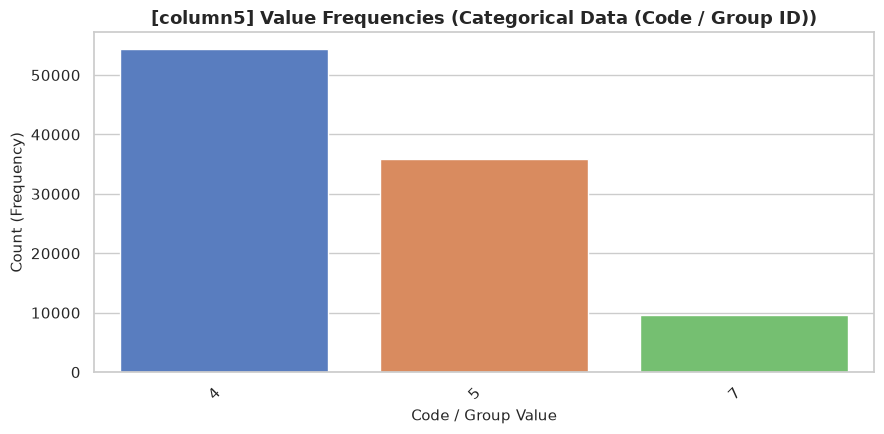

------------------------------------------------------------
📊 Analyzing [column6]:
   - Detected Type : Continuous Data (Quantity / Amount)
   - Total Rows    : 100000
   - Unique Values : 16825 (16.83% of total)


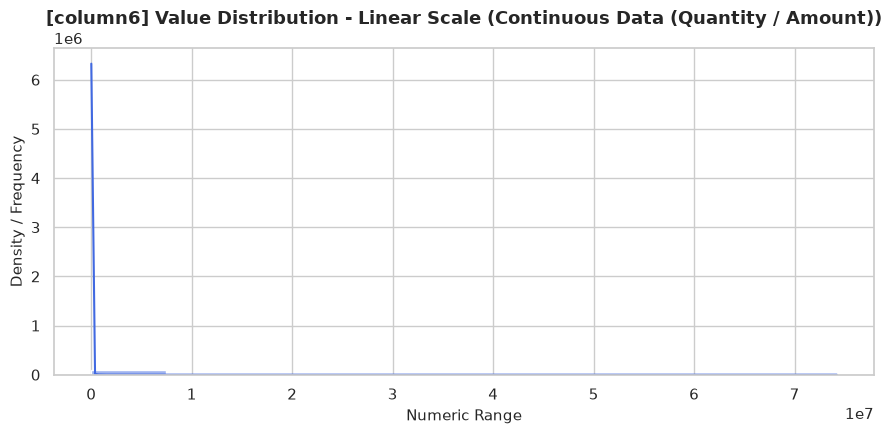

------------------------------------------------------------
📊 Analyzing [column7]:
   - Detected Type : Continuous Data (Quantity / Amount)
   - Total Rows    : 100000
   - Unique Values : 72535 (72.54% of total)


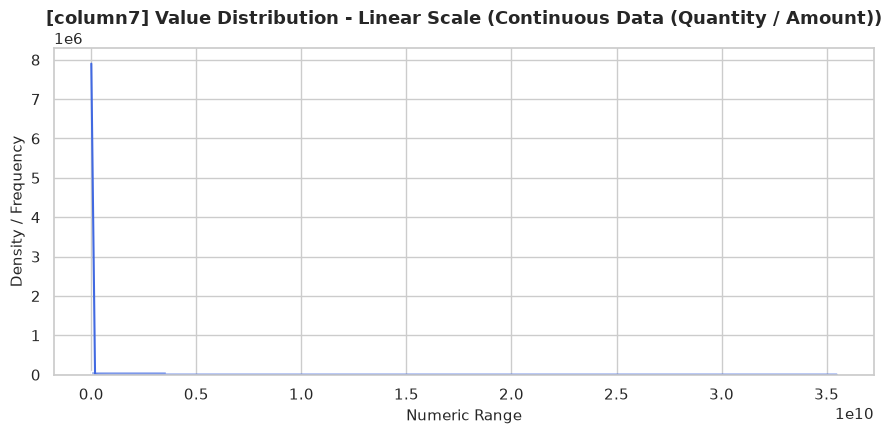

------------------------------------------------------------


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# Specify columns to analyze (e.g., column5, column6, column7)
# Update this list with your actual column names from the DataFrame
target_cols = ['column5', 'column6', 'column7']

for col in target_cols:
    # Data cleaning: Convert to numeric, turn errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    clean_data = df[col].dropna()
    
    if clean_data.empty:
        print(f"⏩ [{col}] skipped: No numeric data found.")
        print("-" * 60)
        continue
        
    # --- AUTOMATIC DATA TYPE DETECTION LOGIC ---
    unique_count = clean_data.nunique()
    total_count = len(clean_data)
    uniqueness_ratio = unique_count / total_count
    
    # Classification rule: Categorical if unique values <= 15 OR unique values make up less than 5% of data
    if unique_count <= 15 or uniqueness_ratio < 0.05:
        data_type = "Categorical Data (Code / Group ID)"
        plot_kind = "bar"
    else:
        data_type = "Continuous Data (Quantity / Amount)"
        plot_kind = "hist"
        
    print(f"📊 Analyzing [{col}]:")
    print(f"   - Detected Type : {data_type}")
    print(f"   - Total Rows    : {total_count}")
    print(f"   - Unique Values : {unique_count} ({uniqueness_ratio:.2%} of total)")
    
    # --- ADAPTIVE VISUALIZATION ---
    plt.figure(figsize=(9, 4.5))
    
    if plot_kind == "bar":
        # A) Categorical: Show frequency of each distinct code/value
        value_counts = clean_data.value_counts().sort_index()
        
        # If there are too many unique categories to fit nicely, show only the top 15
        if len(value_counts) > 15:
            value_counts = value_counts.head(15)
            plt.title(f"[{col}] Top 15 Frequencies ({data_type})", fontsize=13, fontweight='bold')
        else:
            plt.title(f"[{col}] Value Frequencies ({data_type})", fontsize=13, fontweight='bold')
            
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, palette="muted")
        plt.xlabel("Code / Group Value", fontsize=11)
        plt.ylabel("Count (Frequency)", fontsize=11)
        plt.xticks(rotation=45, ha='right')
        
    else:
        # B) Continuous: Show the overall distribution density
        # Apply a log scale automatically if the scale difference spans over 100x and values are positive
        if clean_data.max() / (clean_data.min() + 1e-5) > 100 and clean_data.min() > 0:
            sns.histplot(clean_data, kde=True, color="forestgreen", bins=10, log_scale=True)
            plt.title(f"[{col}] Value Distribution - Log Scale ({data_type})", fontsize=13, fontweight='bold')
        else:
            sns.histplot(clean_data, kde=True, color="royalblue", bins=10)
            plt.title(f"[{col}] Value Distribution - Linear Scale ({data_type})", fontsize=13, fontweight='bold')
            
        plt.xlabel("Numeric Range", fontsize=11)
        plt.ylabel("Density / Frequency", fontsize=11)
        
    plt.tight_layout()
    plt.show()
    print("-" * 60)


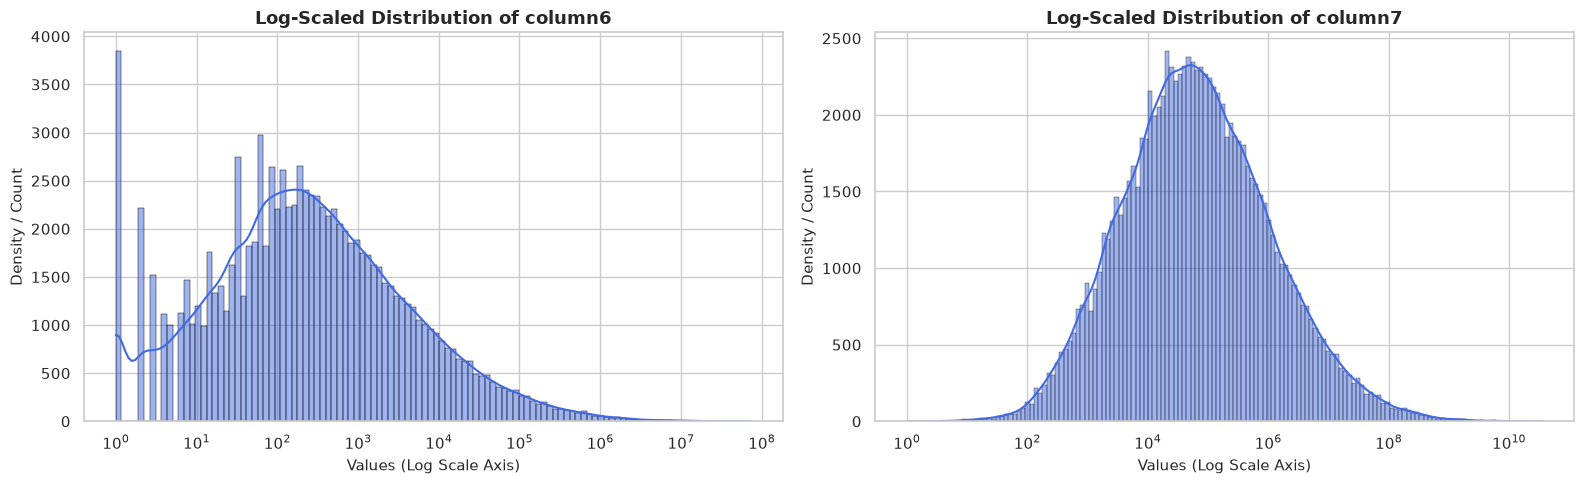

In [34]:
# 100% English Labels & Variables
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(['column6', 'column7']):
    clean_series = pd.to_numeric(df[col], errors='coerce').dropna()
    
    # Keep only values strictly greater than 0 for log transformation
    positive_data = clean_series[clean_series > 0]
    
    # Render with log_scale=True
    sns.histplot(positive_data, kde=True, log_scale=True, ax=axes[i], color='royalblue', edgecolor='black')
    
    axes[i].set_title(f"Log-Scaled Distribution of {col}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Values (Log Scale Axis)", fontsize=11)
    axes[i].set_ylabel("Density / Count", fontsize=11)

plt.tight_layout()
plt.show()


/tmp/ipykernel_26867/3409683228.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_26867/3409683228.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


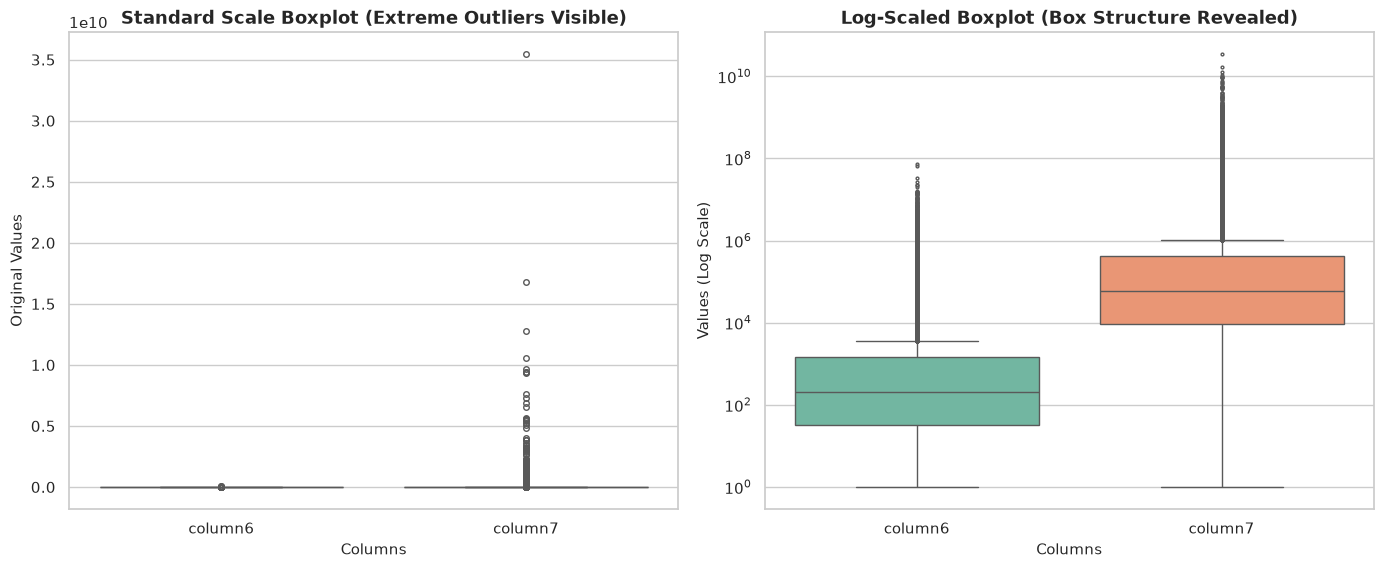

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# Prepare columns
cols_to_plot = ['column6', 'column7']
plot_data_list = []

for col in cols_to_plot:
    # Clean data to numeric
    clean_series = pd.to_numeric(df[col], errors='coerce').dropna()
    
    # Create temporary dataframe for seaborn formatting
    temp_df = pd.DataFrame({
        'Value': clean_series,
        'Column_Name': col
    })
    plot_data_list.append(temp_df)

# Combine datasets
combined_df = pd.concat(plot_data_list, axis=0)

# Create a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 🅰️ Graph 1: Standard Scale Boxplot
sns.boxplot(
    data=combined_df, 
    x='Column_Name', 
    y='Value', 
    ax=axes[0], 
    palette='Set2',
    fliersize=4  # Size of outlier points
)
axes[0].set_title("Standard Scale Boxplot (Extreme Outliers Visible)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Columns", fontsize=11)
axes[0].set_ylabel("Original Values", fontsize=11)

# 🅱️ Graph 2: Log Scale Boxplot (Crucial for heavy-tailed data)
# Filter values > 0 since log(0) is undefined
positive_df = combined_df[combined_df['Value'] > 0]

sns.boxplot(
    data=positive_df, 
    x='Column_Name', 
    y='Value', 
    ax=axes[1], 
    palette='Set2',
    fliersize=2
)
axes[1].set_yscale('log') # Converts the Y-axis to exponential scale (10, 100, 1000...)
axes[1].set_title("Log-Scaled Boxplot (Box Structure Revealed)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Columns", fontsize=11)
axes[1].set_ylabel("Values (Log Scale)", fontsize=11)

plt.tight_layout()
plt.show()


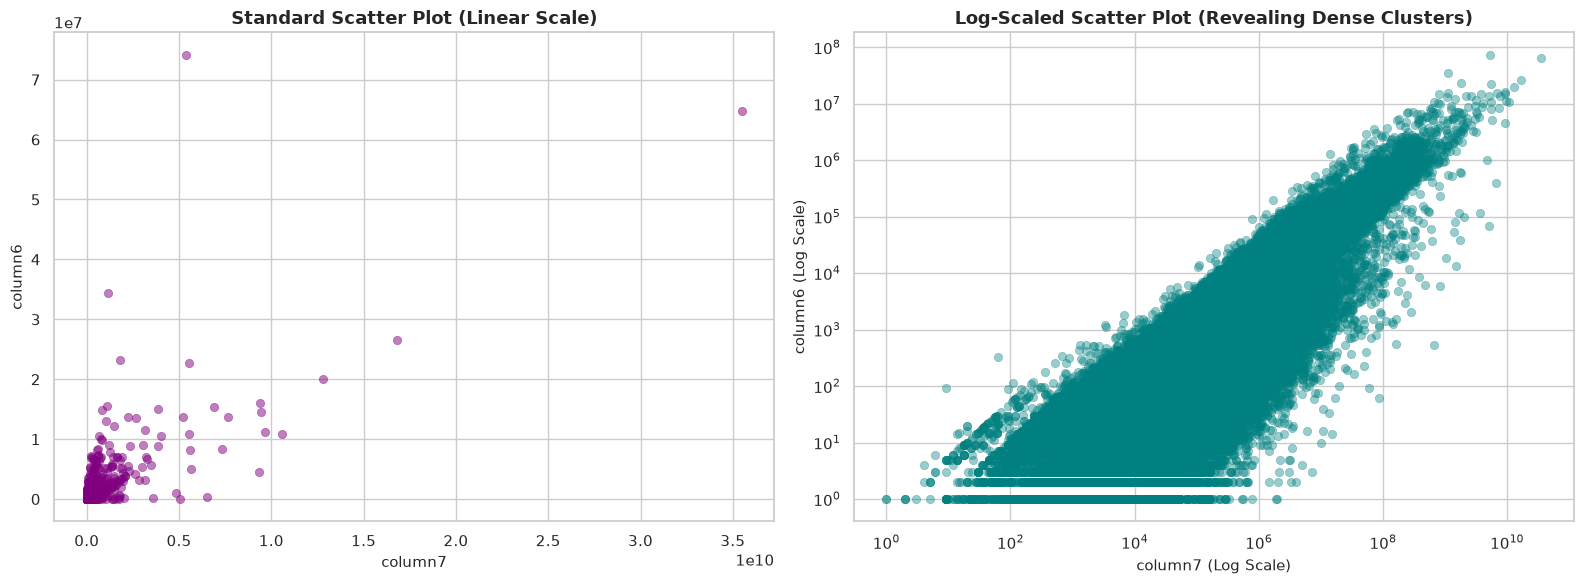

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# 1. Clean and align data (Ensure both columns are numeric and dropped NaNs together)
plot_df = df[['column6', 'column7']].dropna().copy()
plot_df['column7'] = pd.to_numeric(plot_df['column7'], errors='coerce')
plot_df['column6'] = pd.to_numeric(plot_df['column6'], errors='coerce')
plot_df = plot_df.dropna()

# Create a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 🅰️ Graph 1: Standard Linear Scale Scatter Plot
sns.scatterplot(
    data=plot_df,
    x='column7',
    y='column6',
    alpha=0.5,       # Transparency to see density
    color='purple',
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title("Standard Scatter Plot (Linear Scale)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("column7", fontsize=11)
axes[0].set_ylabel("column6", fontsize=11)

# 🅱️ Graph 2: Log-Scaled Scatter Plot (Crucial for heavy-tailed data)
# Filter strictly greater than 0 for both columns since log(0) is undefined
log_df = plot_df[(plot_df['column7'] > 0) & (plot_df['column6'] > 0)]

sns.scatterplot(
    data=log_df,
    x='column7',
    y='column6',
    alpha=0.4,
    color='teal',
    edgecolor=None,
    ax=axes[1]
)
# Apply log scale to both axes
axes[1].set_xscale('log')
axes[1].set_yscale('log')

axes[1].set_title("Log-Scaled Scatter Plot (Revealing Dense Clusters)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("column7 (Log Scale)", fontsize=11)
axes[1].set_ylabel("column6 (Log Scale)", fontsize=11)

plt.tight_layout()
plt.show()


## now we go
* column 5 --> 
* column 6 --> price


In [ ]:
# !pip install matplotlib
# !pip install seaborn